# 2.2 — The instrument menu: futures, forwards, swaps, or just the next month?

> *"Everyone has a plan until they get a margin call."* — the 2022 version of Mike Tyson

## The problem

We know we want to be short roughly $\rho\sigma_S/\sigma_F$ units of *something* against every unit of
exposure. The something can be:

1. an **exchange-traded future** (ICE Endex TTF, cleared, margined daily);
2. a **cleared OTC swap** (financially settled against a published index, e.g. a TTF month-ahead or
   day-ahead index, negotiated bilaterally or via broker, then given up to the clearing house);
3. a **bilateral forward** (physical or financial, under an EFET/ISDA master agreement, no central
   clearing — may or may not be collateralised);
4. **an offsetting position in a neighbouring month** of the same product — i.e. not hedging the exact
   exposure but *transforming* it into a calendar spread;
5. (options — deliberately out of scope; they change the *shape* of risk, not just its size).

Each choice changes three things at once: the **basis** you keep, the **credit** you take, and — the one
engineers most often forget — **when cash moves**. This chapter puts numbers on all three and ends with
what desks actually do.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.market_data import simulate_hub_history
from gashedge.plotting import plot_series
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch2.2")
log.info("Environment ready")

2026-09-13 16:47:00.845 | INFO    | ch2.2 | Environment ready


## 1. The comparison table

| | Exchange future | Cleared OTC swap | Bilateral forward (EFET/ISDA) | Offset in adjacent month |
|---|---|---|---|---|
| **Basis vs your exposure** | hub/tenor of the listed contract only | any index the counterparty will quote (e.g. PEG, odd tenors) | anything, including physical delivery point | leaves a *calendar-spread* exposure |
| **Counterparty credit** | CCP (very low) | CCP (very low) | full bilateral credit risk unless collateralised (CSA) | same as the instrument used |
| **Cash-flow timing** | daily variation margin + initial margin | daily variation margin + IM | none until settlement (or per CSA threshold) | as underlying instrument |
| **Liquidity / cost** | best at the front and near strips (Ch. 1.3) | wider spreads; depends on dealer appetite | widest; negotiation, legal, operational cost | very good — spreads are liquid |
| **Anonymity** | yes (CLOB) | no — dealer knows your flow | no | yes |
| **Flexibility of size/tenor** | 1-lot granularity, listed months only | any size, custom tenors | fully bespoke | listed months only |
| **Regulatory / accounting** | position limits (MiFID II), transparent | EMIR reporting, clearing | EMIR reporting; hedge accounting needs documentation | same as future |
| **Roll risk** | yes — must roll before expiry | can match tenor exactly, no roll | can match exactly | *by construction* you now own the roll |

Two rows deserve attention because they are where hedging programmes actually break: **cash-flow
timing** and **roll risk**. Chapter 2.4 is about the second. Let us quantify the first now.

## 2. The asymmetry that kills: variation margin vs unrealised gains

Picture the classic structure. The market-making books are long a **PEG forward** exposure (from customer
trades under EFET, no daily margin). You hedge by **selling TTF futures**. The economic hedge is good:
if prices rise you lose on the futures and gain on the forward. But:

* the futures loss is **paid in cash every day** to the clearing house (variation margin), plus you must
  post **initial margin** that the CCP raises when volatility rises;
* the forward gain is **an accounting entry** you cannot spend until delivery, months away.

The *net* P&L is fine. The *cash* position is a large, growing hole. If prices quadruple — as they did in
2022 — the hole can exceed the firm's liquidity lines. This is not hypothetical: in September 2022 Sweden
and Finland announced emergency liquidity guarantees of the order of €23 bn and €10 bn to energy companies
facing exactly this margin dynamic on *hedges that were economically correct*, and several German
utilities needed state credit lines for the same reason.

Let us simulate the cash line.

2026-09-13 16:47:00.854 | INFO    | gashedge.market_data | Simulated 750 days of hub history (crisis=True); TTF range 28.9-559.8


2026-09-13 16:47:00.889 | INFO    | ch2.2 | Net economic P&L stays within +/- 30.5 mm EUR while peak cash posted reaches 538.1 mm EUR


,forward MTM (unrealised),futures variation margin (cash),net economic P&L,initial margin requirement,total cash to post
date,,,,,
2023-01-02,0.0,-0.0,0.0,-0.8,-0.8
2023-12-18,1.9,-1.7,0.2,-1.6,-3.3
2024-06-10,16.1,-24.1,-8.0,-30.6,-54.7
2024-09-23,13.0,-17.8,-4.7,-18.7,-36.4
2024-12-02,17.1,-20.8,-3.6,-24.0,-44.7
2025-11-14,-6.9,-1.4,-8.3,-1.4,-2.8


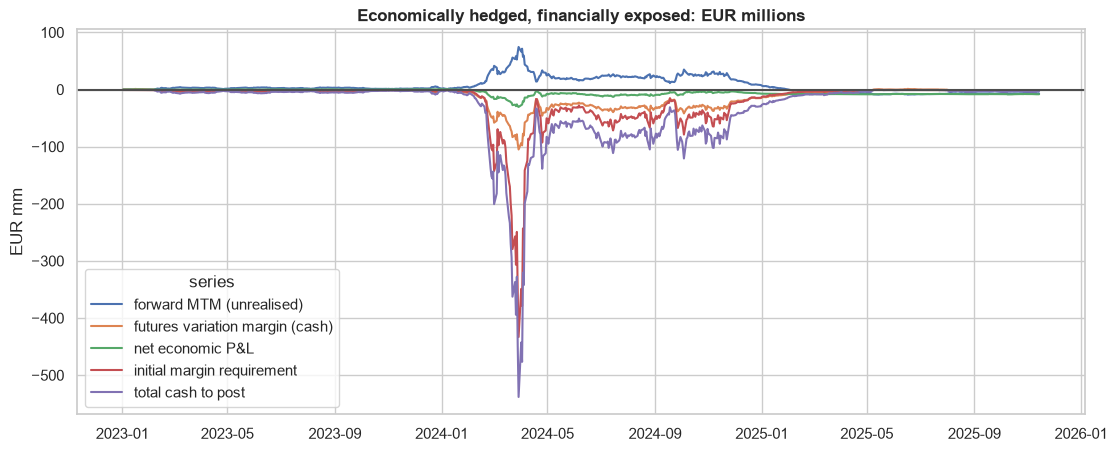

In [2]:
hist = simulate_hub_history(n_days=750, crisis=True, seed=11)
Q_MWH = 200_000                                    # long PEG forward exposure (about 270 lots)
F = hist.TTF
S = hist.PEG
cash = pd.DataFrame(index=hist.index)
cash["forward MTM (unrealised)"] = Q_MWH * (S - S.iloc[0])
cash["futures variation margin (cash)"] = -Q_MWH * (F - F.iloc[0])
cash["net economic P&L"] = cash.iloc[:, 0] + cash.iloc[:, 1]
im_rate = 0.12 + 0.25 * (F / F.iloc[0] - 1).clip(lower=0)        # stylised: IM % rises with price level/vol
cash["initial margin requirement"] = -(im_rate * F * Q_MWH)
cash["total cash to post"] = cash["futures variation margin (cash)"].clip(upper=0) + cash["initial margin requirement"]
fig, ax = plt.subplots(figsize=(13, 5))
plot_series(cash / 1e6, title="Economically hedged, financially exposed: EUR millions", ylabel="EUR mm", ax=ax)
ax.axhline(0, color="0.3")
peak = cash["total cash to post"].min()
log.info("Net economic P&L stays within +/- %.1f mm EUR while peak cash posted reaches %.1f mm EUR",
         cash["net economic P&L"].abs().max() / 1e6, -peak / 1e6)
(cash.iloc[[0, 250, 375, 450, 500, 749]] / 1e6).round(1)

The economic P&L is a flat-ish line near zero — the hedge works. The cash line is a cliff. A hedging
engine therefore needs, alongside the risk limit, a **liquidity stress**: *"if the front month quadruples
in three months, how much cash do the hedges consume, and do we have it?"* (Chapter 3.4 makes this a
standard scenario.)

Three mitigants, each with a price:

* **Collateralised forwards (CSA)** — make the customer leg pay margin too. Symmetric cash, but customers
  resist and it is credit-intensive for them.
* **Cleared OTC** — same margin profile as futures; no help on cash, but full basis flexibility.
* **Liquidity lines / margin financing** — the bank's treasury prices this; it is a real cost of the
  hedge and belongs in $c$ in equation (2.4).

## 3. Basis vs credit: the trade you cannot avoid

Move along the table from left to right and you trade **basis risk for credit and liquidity risk**:

* TTF future against PEG exposure: zero credit risk, full hub basis (Chapter 1.5).
* Cleared PEG swap: zero hub basis (if the index matches), zero credit risk, but wider spread, less depth,
  and the dealer knows your position.
* Bilateral PEG forward: zero basis, but now a credit line, an EFET, netting opinions, and a counterparty
  who may not be there in a crisis — which is when you most need them to be.

There is no free lunch; the *right* answer depends on which risk the firm is better at warehousing. Banks
are, by construction, good at warehousing credit and liquidity risk and *terrible* at explaining basis
losses; that is why the modal answer on a bank desk is *exchange futures first, bespoke instruments for
the residual*.

## 4. The fourth option: offsetting in an adjacent month

Suppose the exposure is Dec-26 and the liquid contract is Oct-26 (M1). Selling Oct against a long Dec
does not remove risk; it *changes* it from an **outright** into a **calendar spread** (long Dec / short
Oct). Whether that is good depends on the correlation and the volatilities — the arithmetic of Chapter 1.4:

$$
\text{Var}(\Delta S - \Delta F) = \sigma_S^2 + \sigma_F^2 - 2\rho\sigma_S\sigma_F
\tag{2.5}
$$

For adjacent months $\rho$ is high (0.9+) and volatilities are similar, so the spread has a small fraction
of the outright variance — an excellent *temporary* hedge. For distant months it is not (Chapter 1.4's
negative variance reductions). The adjacent-month offset is how professionals **buy time**: hedge the
level risk immediately in the liquid front, then migrate the spread risk to the correct month as
liquidity permits ("stack and migrate", Chapter 2.4).

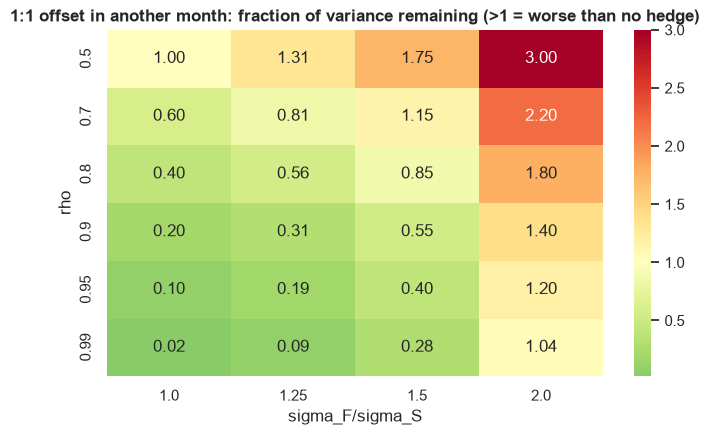

In [3]:
def spread_variance_ratio(rho, sig_s, sig_f):
    return (sig_s**2 + sig_f**2 - 2 * rho * sig_s * sig_f) / sig_s**2

grid = pd.DataFrame([(rho, r) for rho in (0.99, 0.95, 0.9, 0.8, 0.7, 0.5) for r in (1.0, 1.25, 1.5, 2.0)], columns=["rho", "sigma_F/sigma_S"])
grid["remaining_variance_fraction"] = [spread_variance_ratio(rho, 1.0, r) for rho, r in zip(grid.rho, grid["sigma_F/sigma_S"])]
pivot = grid.pivot(index="rho", columns="sigma_F/sigma_S", values="remaining_variance_fraction")
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", center=1.0, ax=ax)
ax.set_title("1:1 offset in another month: fraction of variance remaining (>1 = worse than no hedge)");

## 5. What is global practice?

Across energy desks in London, Amsterdam, Paris, Houston and Singapore the pattern is remarkably
consistent:

1. **Delta is hedged on the most liquid exchange future of the benchmark hub** (TTF for Europe, Henry
   Hub for the US, JKM swaps for Asian LNG) — immediately, in the front or the nearest liquid strip.
2. **Tenor is corrected with exchange-listed calendar spreads** — cheaper than outrights in the back.
3. **Hub basis is either warehoused** (when small and mean-reverting) **or laid off in cleared OTC
   basis swaps** (PEG–TTF, THE–TTF) when it exceeds an internal limit.
4. **Bilateral forwards are used for physical delivery and for customers**, not as hedging instruments —
   precisely because of the cash-flow asymmetry above.
5. **Options are used sparingly by the hedging function** — for *shape* (e.g. asymmetry in inventory
   risk), never as a substitute for delta hedging.

In one sentence: *futures for delta, spreads for tenor, cleared basis swaps for hub, everything else is a
residual with a limit.* That sentence is the architecture of Chapter 2.6.

## 6. Where this leaves us

**Pitfall that leads to the next chapter:** every instrument on the menu is a *proxy* in at least one
dimension — quantity, tenor, or hub. Before designing anything clever we must see exactly how a naïve 1:1
hedge fails in each dimension, in euros. Chapter 2.3.

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** Your book is long 150,000 MWh of PEG forwards (uncollateralised) hedged with short TTF futures. TTF rises from 35 to 140 EUR/MWh over three months and the CCP's initial margin rate goes from 12 % to 35 % of notional. Estimate the cash you must post at the peak. What is your *net economic* P&L, assuming the PEG basis is unchanged?

<details><summary><i>Answer 1</i></summary>

Variation margin on the short futures: $150{,}000 \times (140 - 35) = \mathbf{€15.75\ mm}$ paid out. Initial margin: $0.35 \times 140 \times 150{,}000 = \mathbf{€7.35\ mm}$ (up from $0.12\times35\times150{,}000 = €0.63$ mm). Total cash posted ≈ **€23.1 mm**. Net economic P&L ≈ **0** (the forward gained €15.75 mm on paper, unchanged basis) — you have made no money and need €23 mm of cash. That gap is a *funding cost* (and a survival question) that belongs in the hedging decision.

</details>

**Q2.** Rank the four instruments (future, cleared swap, bilateral forward, adjacent-month offset) by (a) basis risk retained for a PEG Dec-26 exposure, and (b) counterparty credit risk. Which one would you choose for the first ten minutes after receiving a large exposure, and why?

<details><summary><i>Answer 2</i></summary>

(a) Basis risk, low→high: bilateral PEG Dec forward (none) ≈ cleared PEG Dec swap (none, index risk only) < TTF Dec future (hub basis) < TTF front-month offset (hub **and** tenor basis). (b) Credit risk, low→high: future ≈ cleared swap (CCP) < adjacent-month offset (also CCP; same) ≪ bilateral forward (full counterparty risk unless CSA). For the first ten minutes: the **TTF front-month future** (or the liquid Dec future if depth allows) — it is the only instrument you can execute in size, anonymously, within minutes; it removes the level risk, which is 80–95 % of the variance (Chapters 1.4–1.5). Refine tenor and hub afterwards.

</details>

**Q3.** Using equation (2.5): an exposure with $\sigma_S = 1.0$ is offset 1:1 with a neighbouring month with $\sigma_F = 1.25$ and $\rho = 0.95$. What fraction of the variance remains? At what correlation does the offset stop helping at all (fraction = 1)?

<details><summary><i>Answer 3</i></summary>

Remaining fraction $= 1 + 1.5625 - 2(0.95)(1.25) = 2.5625 - 2.375 = \mathbf{0.1875}$ — about 19 % of the original variance, an 81 % reduction. Break-even: $1 + \sigma_F^2/\sigma_S^2 - 2\rho\sigma_F/\sigma_S = 1 \Rightarrow \rho = \sigma_F/(2\sigma_S) = 1.25/2 = \mathbf{0.625}$. Below $\rho = 0.625$ the 1:1 offset with a *more volatile* instrument adds risk. (With the optimal ratio instead of 1:1 the hedge never hurts — Chapter 3.2.)

</details>

**Q4.** A colleague proposes hedging the entire PEG book with bilateral PEG forwards from a single large utility, arguing 'zero basis, zero margin calls'. Give three distinct risks this introduces and one structural mitigant for each.

<details><summary><i>Answer 4</i></summary>

(1) **Counterparty credit / wrong-way risk**: the utility is most likely to default in exactly the crisis where your forwards are most in-the-money (2022 showed utilities are the *stressed* party in a spike). Mitigant: CSA with daily collateral, or clear the trades. (2) **Liquidity/exit risk**: a bilateral forward cannot be closed on a screen; unwinding requires the same counterparty's consent and price. Mitigant: cap bilateral hedges as a fraction of the book; keep the delta in futures. (3) **Concentration and information leakage**: one counterparty sees your entire flow and can price against it; also a single-name concentration limit issue. Mitigant: diversify dealers, use anonymous cleared markets for size, and keep the bilateral channel for the residual basis only. Bonus: 'zero margin calls' is false if a CSA is signed — and dangerous if it isn't.

</details>


---
◀ [Previous](01_why_hedge.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](03_one_to_one_and_mismatches.ipynb)